# Step 1: Dataset Understanding

In [2]:
import pandas as pd

# Load dataset (update path as needed)
df = pd.read_excel("Block_Wise_Water_Electricity_Consumption.xlsx")

# 1. Shape of dataset (rows, columns)
print("Shape:", df.shape)

# 2. Preview first 5 rows
print("\nSample Data:")
print(df.head())

# 3. Column names and datatypes
print("\nInfo:")
print(df.info())

# 4. Check missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# 5. Basic statistics for numeric columns
print("\nSummary Statistics:")
print(df.describe())


Shape: (2160, 14)

Sample Data:
    BLOCKS    FLOOR  ROOMS  MeterNumber  FamilySize    JAN    FEB    MAR  \
0  BLOCK-1  floor-1      1     93268259           2   8.54   7.89   7.15   
1  BLOCK-1  floor-1      2     92029518           4  15.63  13.66  13.74   
2  BLOCK-1  floor-1      3     34511073           5  18.16  16.12  16.12   
3  BLOCK-1  floor-1      4     74864888           1   4.27   4.33   4.10   
4  BLOCK-1  floor-1      5     32840942           3  10.34  10.02  11.01   

     APR    MAY    JUN    JUL    AUG    SEP  
0   7.73   8.28   8.53   7.63   7.44   7.43  
1  13.05  13.80  14.82  13.90  14.67  15.23  
2  16.80  17.81  17.53  17.33  18.33  16.72  
3   4.95   4.79   4.23   4.88   4.23   4.50  
4  12.09  11.52  10.14  11.79  11.68  10.48  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   BLOCKS       2160 non-null   obj

In [3]:
print(df.columns.tolist())

['BLOCKS', 'FLOOR', 'ROOMS', 'MeterNumber', 'FamilySize', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP']


# Step 2: Overall Water Usage

Total Usage per Month:
 JAN    24059.39
FEB    22419.60
MAR    24032.72
APR    24037.14
MAY    24061.11
JUN    23986.32
JUL    24035.69
AUG    24036.26
SEP    23958.72
dtype: float64

Average Usage per Room per Month:
 JAN    11.138606
FEB    10.379444
MAR    11.126259
APR    11.128306
MAY    11.139403
JUN    11.104778
JUL    11.127634
AUG    11.127898
SEP    11.092000
dtype: float64

Highest Usage Month: MAY = 24061.11
Lowest Usage Month: FEB = 22419.6


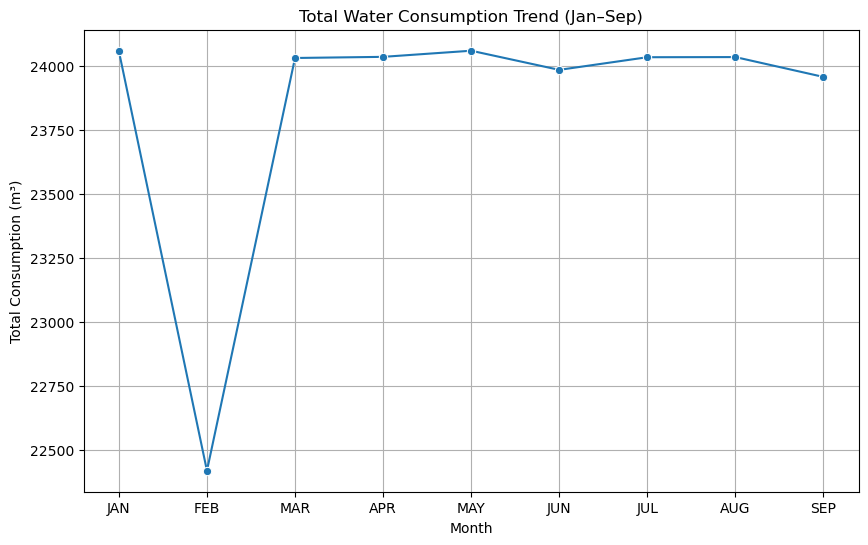

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Month columns from your dataset
months = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP"]
month_data = df[months]

# ---------------------------------------------------------
# Q5: What is the total water consumption per month (Jan–Sep) across all rooms?
# ---------------------------------------------------------
total_usage_per_month = month_data.sum()
print("Total Usage per Month:\n", total_usage_per_month)

# ---------------------------------------------------------
# Q6: What is the average monthly consumption per room?
# ---------------------------------------------------------
avg_usage_per_month = month_data.mean()
print("\nAverage Usage per Room per Month:\n", avg_usage_per_month)

# ---------------------------------------------------------
# Q7: Which month had the highest overall usage? Which had the lowest?
# ---------------------------------------------------------
highest_month = total_usage_per_month.idxmax()
lowest_month = total_usage_per_month.idxmin()
print("\nHighest Usage Month:", highest_month, "=", total_usage_per_month[highest_month])
print("Lowest Usage Month:", lowest_month, "=", total_usage_per_month[lowest_month])

# ---------------------------------------------------------
# Q8: Is there a trend (increasing, decreasing, or stable) in total usage over time?
# ---------------------------------------------------------
plt.figure(figsize=(10,6))
sns.lineplot(x=months, y=total_usage_per_month.values, marker="o")
plt.title("Total Water Consumption Trend (Jan–Sep)")
plt.xlabel("Month")
plt.ylabel("Total Consumption (m³)")
plt.grid(True)
plt.show()

### Interpretation of Results

**Q5 – Total Usage per Month**  
- Each month’s water usage ≈ 24,000 m³.  
- Usage is quite consistent across months.  

**Q6 – Average Usage per Room per Month**  
- Each room uses ≈ 11 m³/month on average.  
- Small differences between months.  

**Q7 – Highest vs Lowest Month**  
- **Highest:** May → 24,061 m³  
- **Lowest:** February → 22,419 m³  
- Slightly higher demand in May, lower in February.  

**Q8 – Trend Over Time**  
- Usage trend is stable from Jan to Sep.  
- No major increase or decrease observed.  


# Step 3: Block-Level Analysis

Total Usage per Block:
               JAN      FEB      MAR      APR      MAY      JUN      JUL  \
BLOCKS                                                                    
BLOCK-1   2436.12  2282.61  2437.67  2445.23  2453.28  2450.52  2420.94   
BLOCK-10  2397.03  2220.97  2379.22  2377.73  2419.04  2389.82  2405.26   
BLOCK-2   2382.08  2212.44  2362.03  2375.01  2367.27  2369.25  2382.26   
BLOCK-3   2410.67  2249.72  2406.86  2412.63  2403.40  2411.86  2402.69   
BLOCK-4   2325.95  2187.38  2335.35  2354.60  2331.18  2342.14  2351.31   
BLOCK-5   2353.38  2207.87  2369.26  2356.87  2365.37  2343.42  2356.62   
BLOCK-6   2467.93  2299.29  2468.92  2442.00  2455.27  2447.11  2471.67   
BLOCK-7   2386.38  2216.85  2383.86  2380.81  2380.95  2378.05  2374.39   
BLOCK-8   2401.46  2236.01  2391.76  2408.98  2404.49  2394.17  2390.47   
BLOCK-9   2498.39  2306.46  2497.79  2483.28  2480.86  2459.98  2480.08   

              AUG      SEP  
BLOCKS                      
BLOCK-1   2443.45

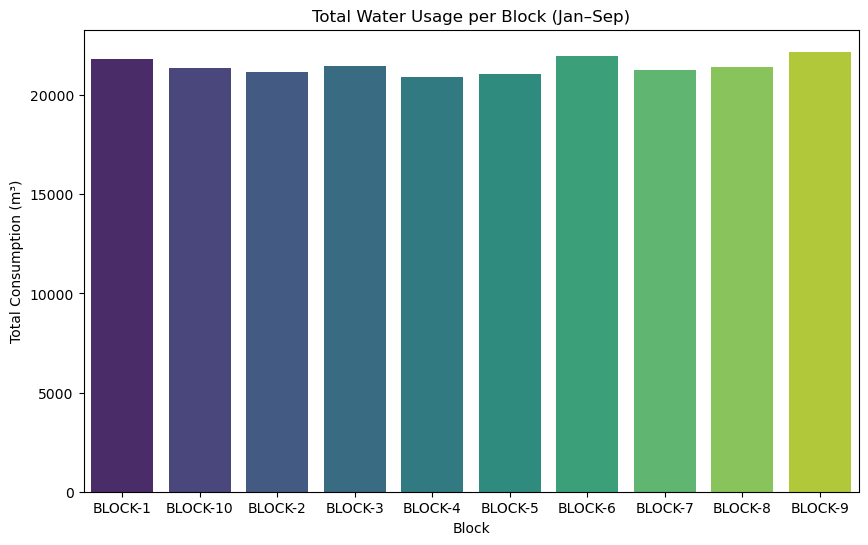

In [5]:
# ---------------------------------------------------------
# Q9: What is the total water usage per block (Jan–Sep)?
# ---------------------------------------------------------
total_usage_per_block = df.groupby("BLOCKS")[months].sum()
print("Total Usage per Block:\n", total_usage_per_block)

# ---------------------------------------------------------
# Q10: What is the average monthly usage per room per block?
# ---------------------------------------------------------
avg_usage_per_block = df.groupby("BLOCKS")[months].mean()
print("\nAverage Monthly Usage per Room per Block:\n", avg_usage_per_block)

# ---------------------------------------------------------
# Q11: Which block consumes the most water overall? Which consumes the least?
# ---------------------------------------------------------
block_total = total_usage_per_block.sum(axis=1)  # sum across months
highest_block = block_total.idxmax()
lowest_block = block_total.idxmin()
print("\nHighest Consuming Block:", highest_block, "=", block_total[highest_block])
print("Lowest Consuming Block:", lowest_block, "=", block_total[lowest_block])

# ---------------------------------------------------------
# Q12: How much does usage vary between blocks (fairness check)?
# ---------------------------------------------------------
block_variance = block_total.var()   # statistical variance
block_std = block_total.std()        # standard deviation
print("\nVariance in Block Usage:", block_variance)
print("Standard Deviation in Block Usage:", block_std)

# Visualization - Compare total block usage
plt.figure(figsize=(10,6))
sns.barplot(x=block_total.index, y=block_total.values, palette="viridis")
plt.title("Total Water Usage per Block (Jan–Sep)")
plt.xlabel("Block")
plt.ylabel("Total Consumption (m³)")
plt.show()

### 📊 Block-wise Water Usage

**Total Usage per Block:** ~2300–2500 m³/month (similar across blocks)  
**Average Room Usage:** ~11 m³/month  

**🏆 Highest vs Lowest Blocks**  
- **Highest:** Block-9 → 22,190 m³  
- **Lowest:** Block-4 → 20,893 m³  
- **Difference:** ~1,300 m³ over 9 months  

**⚖️ Variation**  
- **Variance:** 169,426  
- **Std. Dev.:** ~412 m³  

**✅ Conclusion:**  
- Usage is **balanced** across blocks  
- Slightly higher → Block-9  
- Slightly lower → Block-4

# Step 4: Floor-Level Analysis

Average Monthly Usage per Floor:
                JAN        FEB        MAR        APR        MAY        JUN  \
FLOOR                                                                       
floor-1  11.456875  10.774417  11.470625  11.502583  11.472375  11.465333   
floor-2  11.109750  10.310292  11.032000  11.067833  11.085167  11.071375   
floor-3  10.708083  10.038000  10.777042  10.685333  10.741292  10.726625   
floor-4  11.075792  10.268708  11.119750  11.129875  11.057167  11.012875   
floor-5  11.406375  10.560458  11.287000  11.312500  11.292083  11.286708   
floor-6  11.012500  10.263542  10.985792  11.031125  11.076917  10.973542   
floor-7  11.128750  10.394833  11.143750  11.111250  11.154583  11.117208   
floor-8  11.013333  10.255292  10.981375  11.007042  10.967958  10.947583   
floor-9  11.336000  10.549458  11.339000  11.307208  11.407083  11.341750   

               JUL        AUG        SEP  
FLOOR                                     
floor-1  11.500083  11.495333  1

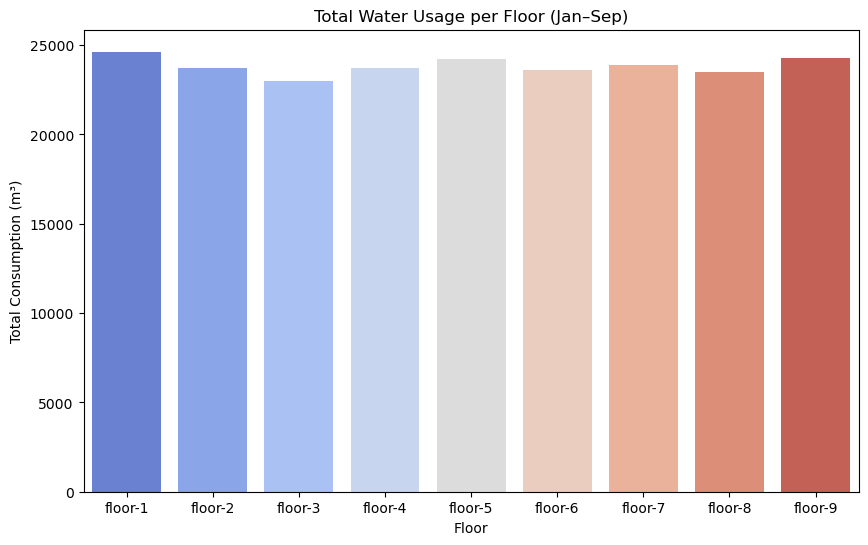

In [6]:
# ---------------------------------------------------------
# Q13: What is the average monthly usage per floor across all blocks?
# ---------------------------------------------------------
avg_usage_per_floor = df.groupby("FLOOR")[months].mean()
print("Average Monthly Usage per Floor:\n", avg_usage_per_floor)

# ---------------------------------------------------------
# Q14: Are top floors using more/less than ground floors?
# ---------------------------------------------------------
floor_total = df.groupby("FLOOR")[months].sum().sum(axis=1)  # total consumption per floor
print("\nTotal Usage per Floor:\n", floor_total)

# Compare ground (1st floor) vs top (9th floor)
if floor_total.loc["floor-1"] > floor_total.loc["floor-9"]:
    print("\nGround floor (floor-1) uses MORE water than top floor (floor-9).")
else:
    print("\nTop floor (floor-9) uses MORE water than ground floor (floor-1).")
    
# ---------------------------------------------------------
# Q15: Which floors show consistently high usage?
# ---------------------------------------------------------
highest_floors = floor_total.sort_values(ascending=False).head(3)
print("\nTop 3 Highest Usage Floors:\n", highest_floors)

# ---------------------------------------------------------
# Q16: Which floors show lowest usage?
# ---------------------------------------------------------
lowest_floors = floor_total.sort_values(ascending=True).head(3)
print("\nTop 3 Lowest Usage Floors:\n", lowest_floors)

# ---------------------------------------------------------
# Visualization: Compare total usage per floor
# ---------------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=floor_total.index, y=floor_total.values, palette="coolwarm")
plt.title("Total Water Usage per Floor (Jan–Sep)")
plt.xlabel("Floor")
plt.ylabel("Total Consumption (m³)")
plt.show()

### 🏢 Floor-wise Water Usage

**Average Monthly Usage per Room:** ~10.7–11.5 m³ (consistent across floors)  

**🏆 Highest Usage Floors**  
- **Floor-1 (Ground):** 24,633 m³  
- **Floor-9 (Top):** 24,309 m³  
- **Floor-5:** 24,233 m³  

**📉 Lowest Usage Floors**  
- **Floor-3:** 23,014 m³  
- **Floor-8:** 23,505 m³  
- **Floor-6:** 23,608 m³  

**🆚 Ground vs Top**  
- Ground floor uses **slightly more** than Top floor  

**✅ Conclusion:**  
- Water usage is **well balanced** across floors  
- Highest → Floor-1  
- Lowest → Floor-3


# Step 5: Room-Level Analysis

Top 10 Rooms by Total Usage:
       BLOCKS    FLOOR  ROOMS  Total_Usage
457   BLOCK-3  floor-2     26       167.63
1587  BLOCK-8  floor-4     76       164.10
639   BLOCK-3  floor-9    208       164.05
1922  BLOCK-9  floor-9    195       163.54
1179  BLOCK-6  floor-5    100       162.93
508   BLOCK-3  floor-4     77       162.88
1223  BLOCK-6  floor-6    144       162.42
1349  BLOCK-7  floor-3     54       162.34
326   BLOCK-2  floor-5    111       162.25
635   BLOCK-3  floor-9    204       161.88


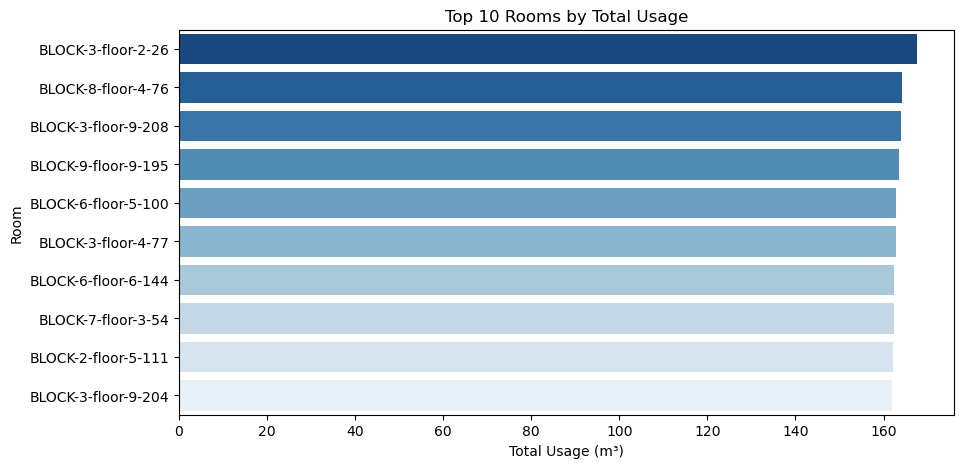


Lowest 10 Rooms by Total Usage:
        BLOCKS    FLOOR  ROOMS  Total_Usage
475    BLOCK-3  floor-2     44        38.40
2103  BLOCK-10  floor-7    160        38.49
2061  BLOCK-10  floor-5    118        38.71
808    BLOCK-4  floor-7    161        38.72
337    BLOCK-2  floor-6    122        38.74
1013   BLOCK-5  floor-7    150        38.82
462    BLOCK-3  floor-2     31        38.91
1655   BLOCK-8  floor-6    144        38.91
1281   BLOCK-6  floor-9    202        38.99
1472   BLOCK-7  floor-8    177        39.12


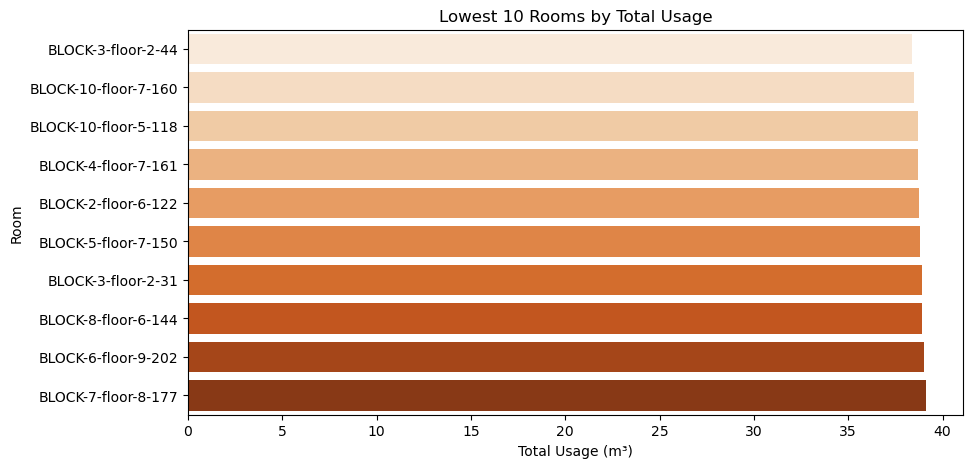


Top 10 Most Stable Rooms (Low Variation):
        BLOCKS    FLOOR  ROOMS  Usage_STD
377    BLOCK-2  floor-7    162   0.119838
1013   BLOCK-5  floor-7    150   0.120416
1260   BLOCK-6  floor-8    181   0.148745
1693   BLOCK-8  floor-8    182   0.151575
1153   BLOCK-6  floor-4     74   0.154146
1931   BLOCK-9  floor-9    204   0.157003
905    BLOCK-5  floor-2     42   0.159330
2058  BLOCK-10  floor-5    115   0.161254
868    BLOCK-5  floor-1      5   0.166842
2000  BLOCK-10  floor-3     57   0.168234


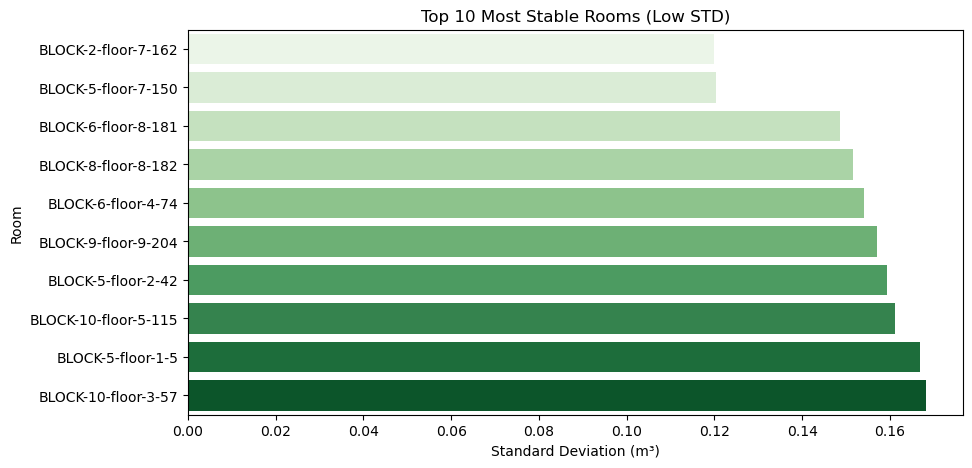


Top 10 Rooms with Highest Variation in Usage:
        BLOCKS    FLOOR  ROOMS  Usage_STD
1792   BLOCK-9  floor-3     65   1.630995
477    BLOCK-3  floor-2     46   1.561253
78     BLOCK-1  floor-4     79   1.502249
1999  BLOCK-10  floor-3     56   1.483639
352    BLOCK-2  floor-6    137   1.480097
181    BLOCK-1  floor-8    182   1.462429
1630   BLOCK-8  floor-5    119   1.457330
50     BLOCK-1  floor-3     51   1.449012
1730   BLOCK-9  floor-1      3   1.443070
37     BLOCK-1  floor-2     38   1.436907


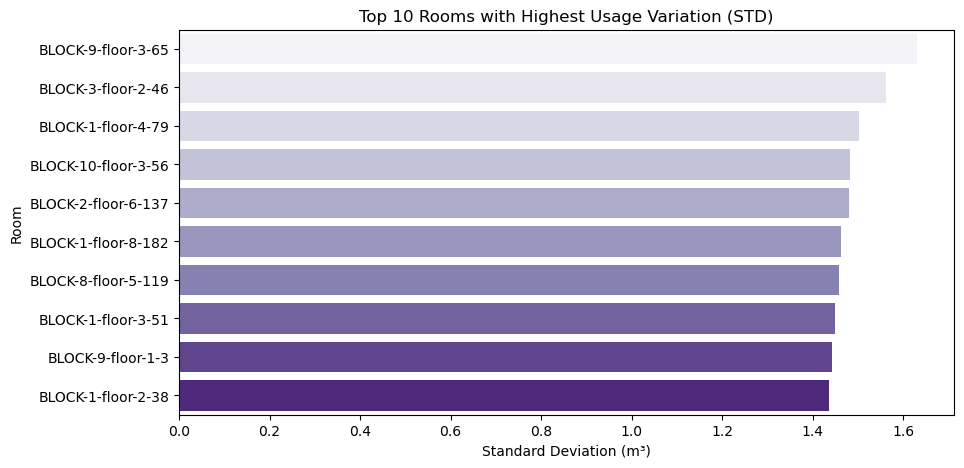


Rooms with Zero or Near-Zero Usage:
 Empty DataFrame
Columns: [BLOCKS, FLOOR, ROOMS, Total_Usage]
Index: []


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

months = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP"]

# Derived columns
df["Total_Usage"] = df[months].sum(axis=1)
df["Usage_STD"]   = df[months].std(axis=1)
df["Room_Label"]  = df["BLOCKS"].astype(str) + "-" + df["FLOOR"].astype(str) + "-" + df["ROOMS"].astype(str)

# --------------------------------
# Q17: Top 10 highest consuming rooms
# --------------------------------
top_rooms = df.sort_values("Total_Usage", ascending=False).head(10)
print("Top 10 Rooms by Total Usage:")
print(top_rooms[["BLOCKS","FLOOR","ROOMS","Total_Usage"]])

plt.figure(figsize=(10,5))
sns.barplot(x="Total_Usage", y="Room_Label", data=top_rooms, palette="Blues_r")
plt.title("Top 10 Rooms by Total Usage")
plt.xlabel("Total Usage (m³)")
plt.ylabel("Room")
plt.show()


# --------------------------------
# Q18: Bottom 10 lowest consuming rooms
# --------------------------------
low_rooms = df.sort_values("Total_Usage").head(10)
print("\nLowest 10 Rooms by Total Usage:")
print(low_rooms[["BLOCKS","FLOOR","ROOMS","Total_Usage"]])

plt.figure(figsize=(10,5))
sns.barplot(x="Total_Usage", y="Room_Label", data=low_rooms, palette="Oranges")
plt.title("Lowest 10 Rooms by Total Usage")
plt.xlabel("Total Usage (m³)")
plt.ylabel("Room")
plt.show()


# --------------------------------
# Q19: Stable usage (low variation)
# --------------------------------
low_var = df.sort_values("Usage_STD").head(10)
print("\nTop 10 Most Stable Rooms (Low Variation):")
print(low_var[["BLOCKS","FLOOR","ROOMS","Usage_STD"]])

plt.figure(figsize=(10,5))
sns.barplot(x="Usage_STD", y="Room_Label", data=low_var, palette="Greens")
plt.title("Top 10 Most Stable Rooms (Low STD)")
plt.xlabel("Standard Deviation (m³)")
plt.ylabel("Room")
plt.show()


# --------------------------------
# Q20: Irregular users (high variation)
# --------------------------------
high_var = df.sort_values("Usage_STD", ascending=False).head(10)
print("\nTop 10 Rooms with Highest Variation in Usage:")
print(high_var[["BLOCKS","FLOOR","ROOMS","Usage_STD"]])

plt.figure(figsize=(10,5))
sns.barplot(x="Usage_STD", y="Room_Label", data=high_var, palette="Purples")
plt.title("Top 10 Rooms with Highest Usage Variation (STD)")
plt.xlabel("Standard Deviation (m³)")
plt.ylabel("Room")
plt.show()


# --------------------------------
# Q21: Zero or near-zero usage rooms
# --------------------------------
zero_usage_rooms = df[df["Total_Usage"] <= 0.1][["BLOCKS", "FLOOR", "ROOMS", "Total_Usage"]]
print("\nRooms with Zero or Near-Zero Usage:\n", zero_usage_rooms)



### 🏠 Room-Level Water Usage

**🔝 Top Consumers (Q17)**  
- Top 10 rooms: ~162–168 m³ (Jan–Sep)  
- **Highest:** Block-3, Floor-2, Room-26 → 167.63 m³  
- High-usage rooms are scattered across blocks/floors  

**🔻 Lowest Consumers (Q18)**  
- Bottom 10 rooms: ~38–39 m³  
- **Lowest:** Block-3, Floor-2, Room-44 → 38.40 m³  
- Only ~¼ of top rooms’ usage  

**📊 Stable Usage (Q19)**  
- Top 10 stable rooms: STD ~0.12–0.17 m³  
- **Most stable:** Block-2, Floor-7, Room-162 → STD 0.12  
- Indicates **steady & predictable usage**  

**⚡ Irregular Users (Q20)**  
- Top 10 irregular rooms: STD ~1.4–1.6 m³  
- **Most irregular:** Block-9, Floor-3, Room-65 → STD 1.63  
- Shows **sudden fluctuations or seasonal spikes**  

**🚫 Zero Usage (Q21)**  
- ✅ No rooms with zero or near-zero usage  
- All rooms are actively consuming water  

**✅ Summary**  
- Usage ranges **38 → 168 m³ per room** (9 months)  
- Some rooms are **very stable**, others **fluctuate heavily**  
- **All rooms are connected & using water**


# Step 6: Family Size & Equity

Average Usage per Family Size:
    FamilySize  Total_Usage
0           1    40.627017
1           2    69.626154
2           3    98.457247
3           4   127.570000
4           5   156.449116


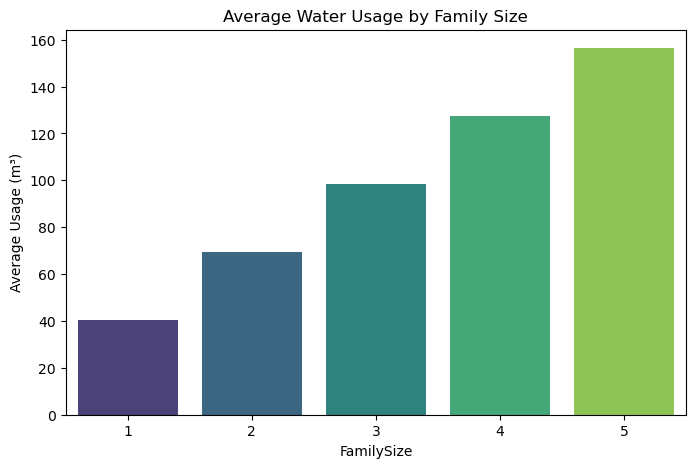

In [8]:
# Q22: What is the average usage per family size group (1, 2, 3, 4, 5)?
# Average usage by family size
avg_usage_family = df.groupby("FamilySize")["Total_Usage"].mean().reset_index()
print("Average Usage per Family Size:\n", avg_usage_family)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x="FamilySize", y="Total_Usage", data=avg_usage_family, palette="viridis")
plt.title("Average Water Usage by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Average Usage (m³)")
plt.show()

### 👨‍👩‍👧 Family Size vs Water Usage (Q22)

**Water Usage by Family Size:**  
- **1 member:** ~40.6 m³  
- **2 members:** ~69.6 m³  
- **3 members:** ~98.5 m³  
- **4 members:** ~127.6 m³  
- **5 members:** ~156.4 m³  

**📌 Trend:**  
- Usage **increases almost linearly** with family size  
- **Per person**, larger families use **less water**, showing **efficiency**


    BLOCKS    FLOOR  ROOMS  FamilySize  Total_Usage  Per_Capita_Usage
0  BLOCK-1  floor-1      1           2        70.62         35.310000
1  BLOCK-1  floor-1      2           4       128.50         32.125000
2  BLOCK-1  floor-1      3           5       154.92         30.984000
3  BLOCK-1  floor-1      4           1        40.28         40.280000
4  BLOCK-1  floor-1      5           3        99.07         33.023333


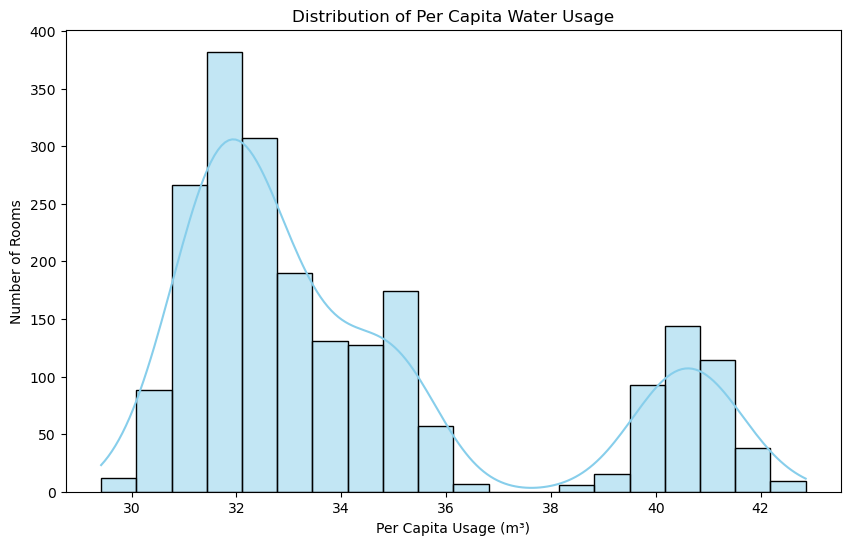

In [9]:
# Q23: Per capita consumption for each room
# Per capita consumption
df["Per_Capita_Usage"] = df["Total_Usage"] / df["FamilySize"]
print(df[["BLOCKS", "FLOOR", "ROOMS", "FamilySize", "Total_Usage", "Per_Capita_Usage"]].head())

# Optional plot
plt.figure(figsize=(10,6))
sns.histplot(df["Per_Capita_Usage"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Per Capita Water Usage")
plt.xlabel("Per Capita Usage (m³)")
plt.ylabel("Number of Rooms")
plt.show()

### 🚰 Per Capita Water Usage (Q23)

**Per-Person Usage:**  
- Most rooms: **30–40 m³ per person**  
- **Single-member families:** ~40 m³ (higher per person)  
- **Larger families:** lower per-person usage  

**📌 Insight:**  
- **Sharing resources in bigger families improves water efficiency**


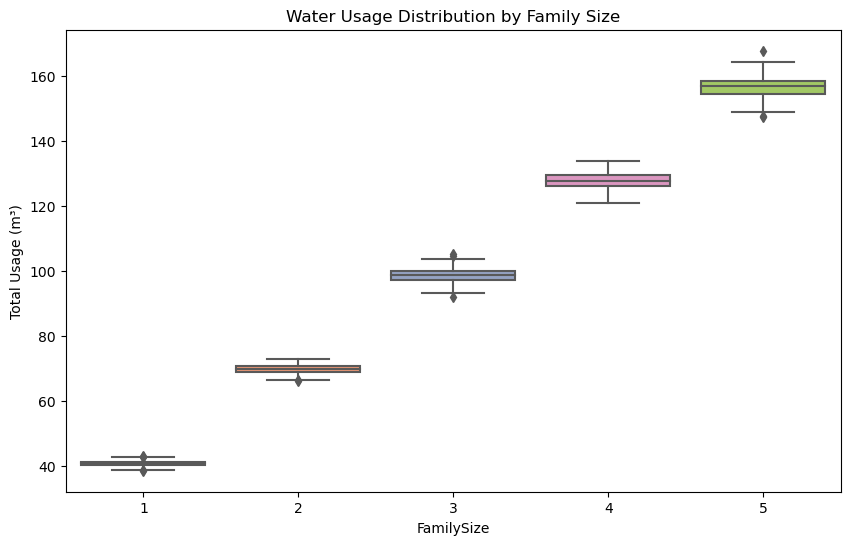

In [10]:
# Q24: Families of same size consuming more/less

# Boxplot to compare usage within same family size
plt.figure(figsize=(10,6))
sns.boxplot(x="FamilySize", y="Total_Usage", data=df, palette="Set2")
plt.title("Water Usage Distribution by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Total Usage (m³)")
plt.show()

### 📊 Usage Variation within Same Family Size (Q24)

**Trend:** Larger families consume **more water in total**.  
**Spread:** Variation shows not all families of same size use water **equally**.  
**Outliers:** Some families use **unusually more or less** than others in their group.  

**📌 Insight:** Even within same family size, **efficiency differs** — habits and lifestyle matter.


In [11]:
# Q25: Rooms/families above equity benchmark (over-using)

# Define benchmark as mean + 1 std dev of per capita usage
benchmark = df["Per_Capita_Usage"].mean() + df["Per_Capita_Usage"].std()
over_using = df[df["Per_Capita_Usage"] > benchmark]

print("Rooms/Families Above Equity Benchmark (Over-using):\n", over_using[["BLOCKS","FLOOR","ROOMS","FamilySize","Per_Capita_Usage"]])

Rooms/Families Above Equity Benchmark (Over-using):
         BLOCKS    FLOOR  ROOMS  FamilySize  Per_Capita_Usage
3      BLOCK-1  floor-1      4           1             40.28
9      BLOCK-1  floor-1     10           1             40.70
20     BLOCK-1  floor-1     21           1             41.28
21     BLOCK-1  floor-1     22           1             40.06
24     BLOCK-1  floor-2     25           1             40.66
...        ...      ...    ...         ...               ...
2141  BLOCK-10  floor-9    198           1             39.80
2144  BLOCK-10  floor-9    201           1             39.79
2145  BLOCK-10  floor-9    202           1             40.20
2146  BLOCK-10  floor-9    203           1             39.98
2150  BLOCK-10  floor-9    207           1             41.69

[419 rows x 5 columns]


### 📊 Over-Using Families (Above Fair Share)

**What we checked:**  
- Calculated **average per-person water usage** across all families.  
- Added **1 standard deviation** → set a **benchmark for “normal” usage**.  
- Any family **above this benchmark** is considered **overusing**.  

**What we found:**  
- **419 rooms/families** exceed the benchmark.  
- Most are **single-member families**.  

**Why this happens:**  
- Single-person households have **less shared water use**, so **per-person consumption is higher**.  
- Could indicate **inefficient usage or wastage**.  

**Key Insight:**  
- **Larger families** → lower per-person usage due to sharing.  
- **Single-person households** → often exceed fair share → may **waste water**.


In [12]:
# Q26: Rooms/families below benchmark (efficient or under-using)

under_using = df[df["Per_Capita_Usage"] <= benchmark]

print("Rooms/Families Below Benchmark (Efficient/Under-using):\n", under_using[["BLOCKS","FLOOR","ROOMS","FamilySize","Per_Capita_Usage"]])


Rooms/Families Below Benchmark (Efficient/Under-using):
         BLOCKS    FLOOR  ROOMS  FamilySize  Per_Capita_Usage
0      BLOCK-1  floor-1      1           2         35.310000
1      BLOCK-1  floor-1      2           4         32.125000
2      BLOCK-1  floor-1      3           5         30.984000
4      BLOCK-1  floor-1      5           3         33.023333
5      BLOCK-1  floor-1      6           2         35.150000
...        ...      ...    ...         ...               ...
2155  BLOCK-10  floor-9    212           4         32.507500
2156  BLOCK-10  floor-9    213           3         32.553333
2157  BLOCK-10  floor-9    214           4         31.702500
2158  BLOCK-10  floor-9    215           2         34.155000
2159  BLOCK-10  floor-9    216           5         30.210000

[1741 rows x 5 columns]


### 📊 Efficient / Under-Using Families

**Result:** 1,741 rooms/families fall **below the benchmark**.  

**Pattern:** Mostly **larger families (2–5 members)**.  

**Insight:** Bigger families tend to **share water more efficiently**, leading to **lower per-person consumption**.


# Step 7: Usage Distribution

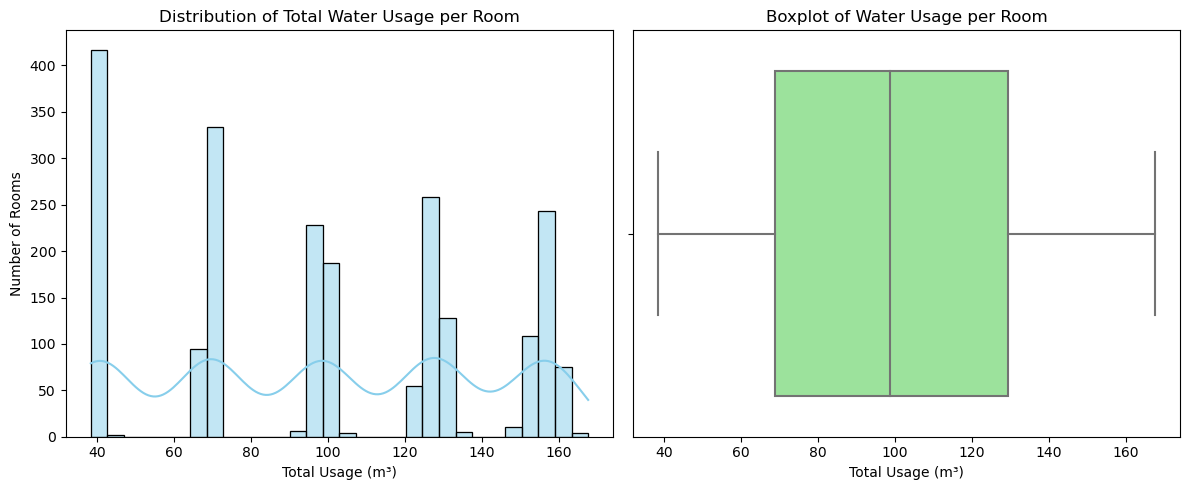

In [14]:
# Q27: Distribution of water usage per room
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df['Total_Usage'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Total Water Usage per Room")
plt.xlabel("Total Usage (m³)")
plt.ylabel("Number of Rooms")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['Total_Usage'], color='lightgreen')
plt.title("Boxplot of Water Usage per Room")
plt.xlabel("Total Usage (m³)")

plt.tight_layout()
plt.show()

### 📊 Water Usage Distribution (Histogram & Boxplot)

**Histogram (left side):**  
- Usage mostly **40–170 m³**.  
- Peaks around **40, 70, 100, 130, 160 m³** → shows **different family size groups** driving usage.  
- **Multiple clusters** → distribution is not smooth.  

**Boxplot (right side):**  
- **Median usage:** ≈100 m³  
- **Middle 50% (IQR):** ~70–130 m³  
- Few rooms at **low (~40 m³)** and **high (~160+ m³)** ends, but **not extreme outliers**  

**👉 Interpretation:**  
- Most rooms use water **in proportion to family size**.  
- Multi-modal pattern shows **different family categories**.  
- Boxplot shows **overall balance** with **some variation**, but **few extreme cases**.


Top 10% rooms use 15.99% of total water
Bottom 10% rooms use 4.03% of total water


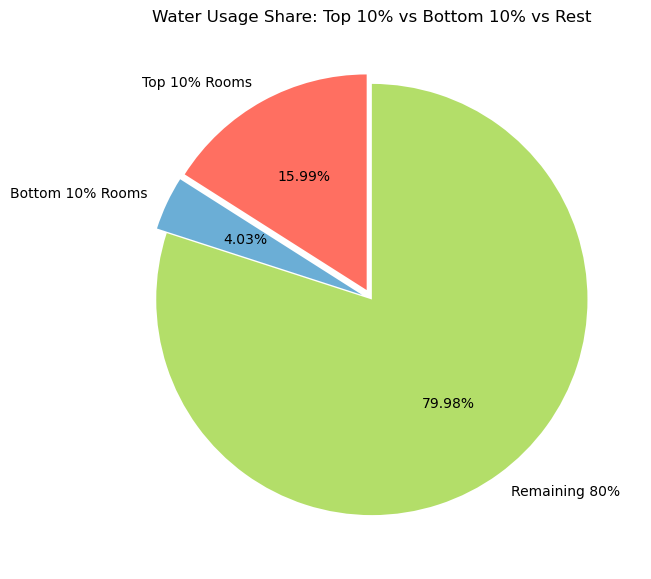

In [15]:
# Q28: Top 10% vs Bottom 10% usage
# Sort rooms by usage
df_sorted = df.sort_values("Total_Usage", ascending=False)
n_rooms = len(df_sorted)
top_10pct_count = int(0.1 * n_rooms)
bottom_10pct_count = int(0.1 * n_rooms)

top_10_usage = df_sorted['Total_Usage'][:top_10pct_count].sum()
bottom_10_usage = df_sorted['Total_Usage'][-bottom_10pct_count:].sum()
total_usage = df_sorted['Total_Usage'].sum()

print(f"Top 10% rooms use {top_10_usage/total_usage*100:.2f}% of total water")
print(f"Bottom 10% rooms use {bottom_10_usage/total_usage*100:.2f}% of total water")

import matplotlib.pyplot as plt

# Labels & values
labels = ["Top 10% Rooms", "Bottom 10% Rooms", "Remaining 80%"]
values = [top_10_usage, bottom_10_usage, total_usage - (top_10_usage + bottom_10_usage)]

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    values, 
    labels=labels, 
    autopct="%.2f%%", 
    startangle=90, 
    colors=["#FF6F61","#6BAED6","#B3DE69"],
    explode=(0.05,0.05,0)  # highlight top & bottom 10%
)
plt.title("Water Usage Share: Top 10% vs Bottom 10% vs Rest")
plt.show()


### 📊 Water Consumption by Room Percentiles

**Top 10% rooms:**  
- Consume **16% of total water**  
- Heavy consumers, but **not extreme hoarders** (~1.6× their population share)  

**Bottom 10% rooms:**  
- Consume **4% of total water**  
- Low users → due to **small family size, efficiency, or under-usage**  

**Remaining 80% rooms:**  
- Consume **~80% of total water**  
- Usage is **fairly balanced** across this middle group  

**📌 Interpretation:**  
- Water consumption is **somewhat unequal but not extreme**  
- **Top users** consume **4× more than bottom users**  
- **Middle group** maintains balance


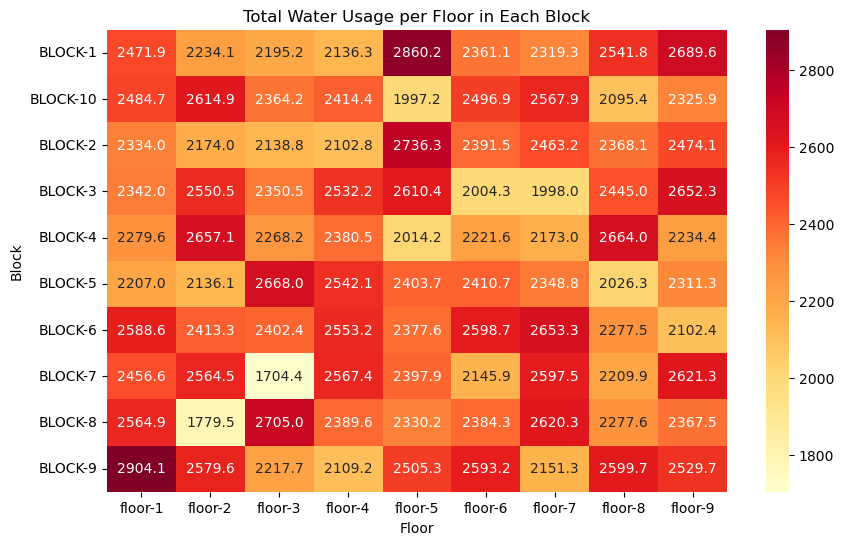

In [15]:
# Q29: Rooms dominating usage by Block/Floor

# Aggregate usage by Block and Floor
block_floor_usage = df.groupby(['BLOCKS','FLOOR'])['Total_Usage'].sum().reset_index()

# Heatmap of usage per floor (rows=blocks, cols=floors)
usage_matrix = block_floor_usage.pivot(index='BLOCKS', columns='FLOOR', values='Total_Usage')

plt.figure(figsize=(10,6))
sns.heatmap(usage_matrix, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Total Water Usage per Floor in Each Block")
plt.ylabel("Block")
plt.xlabel("Floor")
plt.show()

### 📊 Block-Floor Water Usage (Heatmap)

**Highest usage:**  
- **Block-9 floor-1:** ~2900 m³ (**strongest hotspot**)  
- **Block-1 floor-5:** ~2860 m³  
- **Block-2 floor-5:** ~2736 m³  

**Lowest usage:**  
- **Block-7 floor-3:** ~1704 m³  
- **Block-8 floor-2:** ~1779 m³  

**Patterns:**  
- **Block-9:** consistently high across floors  
- **Block-7 & Block-8:** mixed usage, sharp highs & lows  
- **Middle floors (3–5):** big variation across blocks  

**👉 Interpretation:**  
- Heatmap highlights **inefficient floors**  
- Useful for targeting **audits** (leaks, illegal connections, over-usage families)


# Step 8: Time-Based Trends

Top 10 Rooms with Highest Increase (JAN → SEP):
        BLOCKS    FLOOR  ROOMS    JAN    SEP  Usage_Change
1809   BLOCK-9  floor-4     82  15.78  19.07          3.29
78     BLOCK-1  floor-4     79  15.91  19.05          3.14
644    BLOCK-3  floor-9    213  16.02  19.07          3.05
228    BLOCK-2  floor-1     13  15.93  18.90          2.97
1264   BLOCK-6  floor-8    185  12.84  15.67          2.83
103    BLOCK-1  floor-5    104  16.08  18.88          2.80
44     BLOCK-1  floor-2     45  16.02  18.78          2.76
1996  BLOCK-10  floor-3     53  12.89  15.65          2.76
188    BLOCK-1  floor-8    189  12.95  15.67          2.72
1870   BLOCK-9  floor-6    143  16.22  18.86          2.64

Top 10 Rooms with Largest Decrease (JAN → SEP):
        BLOCKS    FLOOR  ROOMS    JAN    SEP  Usage_Change
2109  BLOCK-10  floor-7    166  19.03  15.85         -3.18
737    BLOCK-4  floor-4     90  18.82  15.85         -2.97
1686   BLOCK-8  floor-8    175  18.75  15.82         -2.93
1184   BLOCK-6  fl

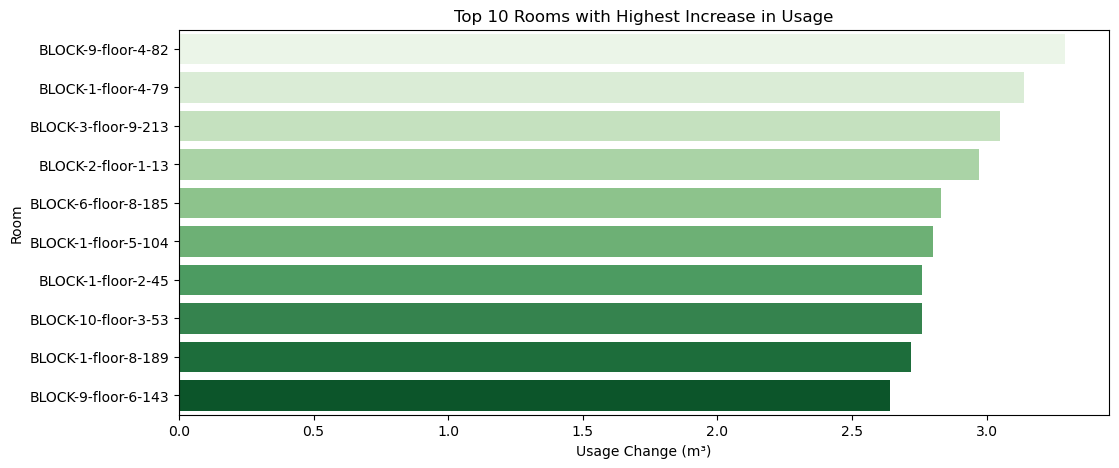

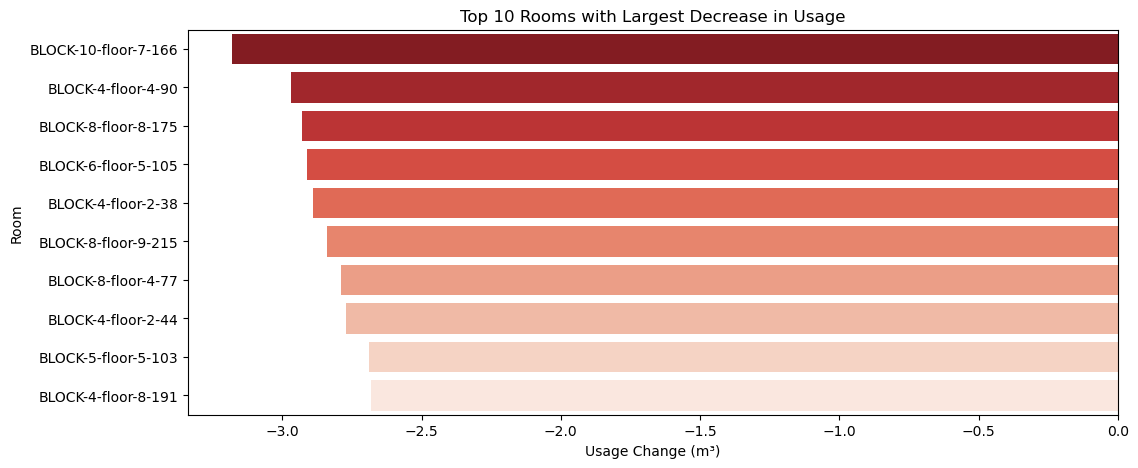

In [16]:
# Q30 & Q31: Rooms with largest increase/decrease JAN → SEP
df['Usage_Change'] = df['SEP'] - df['JAN']

# Top increasing rooms
top_increase = df.sort_values('Usage_Change', ascending=False).head(10)
print("Top 10 Rooms with Highest Increase (JAN → SEP):")
print(top_increase[['BLOCKS','FLOOR','ROOMS','JAN','SEP','Usage_Change']])

# Top decreasing rooms
top_decrease = df.sort_values('Usage_Change').head(10)
print("\nTop 10 Rooms with Largest Decrease (JAN → SEP):")
print(top_decrease[['BLOCKS','FLOOR','ROOMS','JAN','SEP','Usage_Change']])

# Visualizing
plt.figure(figsize=(12,5))
sns.barplot(
    x='Usage_Change', 
    y=top_increase['BLOCKS'] + '-' + top_increase['FLOOR'] + '-' + top_increase['ROOMS'].astype(str),
    data=top_increase, 
    palette="Greens"
)
plt.title("Top 10 Rooms with Highest Increase in Usage")
plt.xlabel("Usage Change (m³)")
plt.ylabel("Room")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(
    x='Usage_Change', 
    y=top_decrease['BLOCKS'] + '-' + top_decrease['FLOOR'] + '-' + top_decrease['ROOMS'].astype(str),
    data=top_decrease, 
    palette="Reds_r"
)
plt.title("Top 10 Rooms with Largest Decrease in Usage")
plt.xlabel("Usage Change (m³)")
plt.ylabel("Room")
plt.show()

### 🔼 Top 10 Rooms with Highest Increase (JAN → SEP)

**Biggest jump:** BLOCK-9 floor-4 room-82 → +3.29 m³  
**Other increases:** +2.6 to +3.1 m³  
**Mostly from:** BLOCK-1, BLOCK-6, BLOCK-9, BLOCK-10  

**👉 Interpretation:**  
- Rooms may have **higher family size, seasonal demand, or possible leak/extra usage**

---

### 🔽 Top 10 Rooms with Largest Decrease (JAN → SEP)

**Biggest drop:** BLOCK-10 floor-7 room-166 → -3.18 m³  
**Other drops:** -2.6 to -3.0 m³  
**Mostly from:** BLOCK-4, BLOCK-8, BLOCK-6  

**👉 Interpretation:**  
- Could indicate **reduced occupancy, repairs, or more efficient usage**

**✅ Visualization:**  
- **Green bars:** high rise rooms  
- **Red bars:** high drop rooms


In [17]:
print(df.columns)

Index(['BLOCKS', 'FLOOR', 'ROOMS', 'MeterNumber', 'FamilySize', 'JAN', 'FEB',
       'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'Total_Usage',
       'Usage_STD', 'Room_Label', 'Per_Capita_Usage', 'Usage_Category',
       'Usage_Change'],
      dtype='object')


In [18]:
# Q32: Blocks/Floors with stable usage across all months

# Calculate standard deviation per floor
floor_usage = df.groupby(['BLOCKS','FLOOR']).agg(list).reset_index()

# Calculate monthly std per floor
monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP']
floor_usage['STD'] = floor_usage[monthly_cols].apply(lambda x: pd.Series(x[0]).std(), axis=1)

stable_floors = floor_usage.sort_values('STD').head(10)
print("Floors with Most Stable Usage Across Months:")
print(stable_floors[['BLOCKS','FLOOR','STD']])

Floors with Most Stable Usage Across Months:
     BLOCKS    FLOOR       STD
43  BLOCK-4  floor-8  3.585330
3   BLOCK-1  floor-4  3.778933
62  BLOCK-6  floor-9  3.780801
52  BLOCK-5  floor-8  3.856768
18  BLOCK-2  floor-1  3.868378
81  BLOCK-9  floor-1  3.910196
23  BLOCK-2  floor-6  3.980639
4   BLOCK-1  floor-5  3.988156
84  BLOCK-9  floor-4  3.993464
83  BLOCK-9  floor-3  4.004425


🔹 Interpretation of Results

Stability here is measured by low standard deviation (STD) across Jan–Sep.

Lower STD → usage didn’t fluctuate much month-to-month.

🏆 Top 10 Most Stable Floors

BLOCK-4 floor-8 → STD ≈ 3.59 (most stable)

BLOCK-1 floor-4 → STD ≈ 3.78

BLOCK-6 floor-9 → STD ≈ 3.78

BLOCK-5 floor-8 → STD ≈ 3.86

BLOCK-2 floor-1 → STD ≈ 3.87

BLOCK-9 floor-1 → STD ≈ 3.91

BLOCK-2 floor-6 → STD ≈ 3.98

BLOCK-1 floor-5 → STD ≈ 3.99

BLOCK-9 floor-4 → STD ≈ 3.99

BLOCK-9 floor-3 → STD ≈ 4.00

👉 These are the floors where water usage habits are consistent across the 9 months — less seasonal variation, stable occupancy, or uniform usage behavior.

Floors with Largest Seasonal Variations:
      BLOCKS    FLOOR  Range
28   BLOCK-3  floor-2  15.15
30   BLOCK-3  floor-4  15.09
11  BLOCK-10  floor-3  15.03
76   BLOCK-8  floor-5  15.01
7    BLOCK-1  floor-8  14.99
0    BLOCK-1  floor-1  14.90
49   BLOCK-5  floor-5  14.90
88   BLOCK-9  floor-8  14.89
70   BLOCK-7  floor-8  14.89
27   BLOCK-3  floor-1  14.88


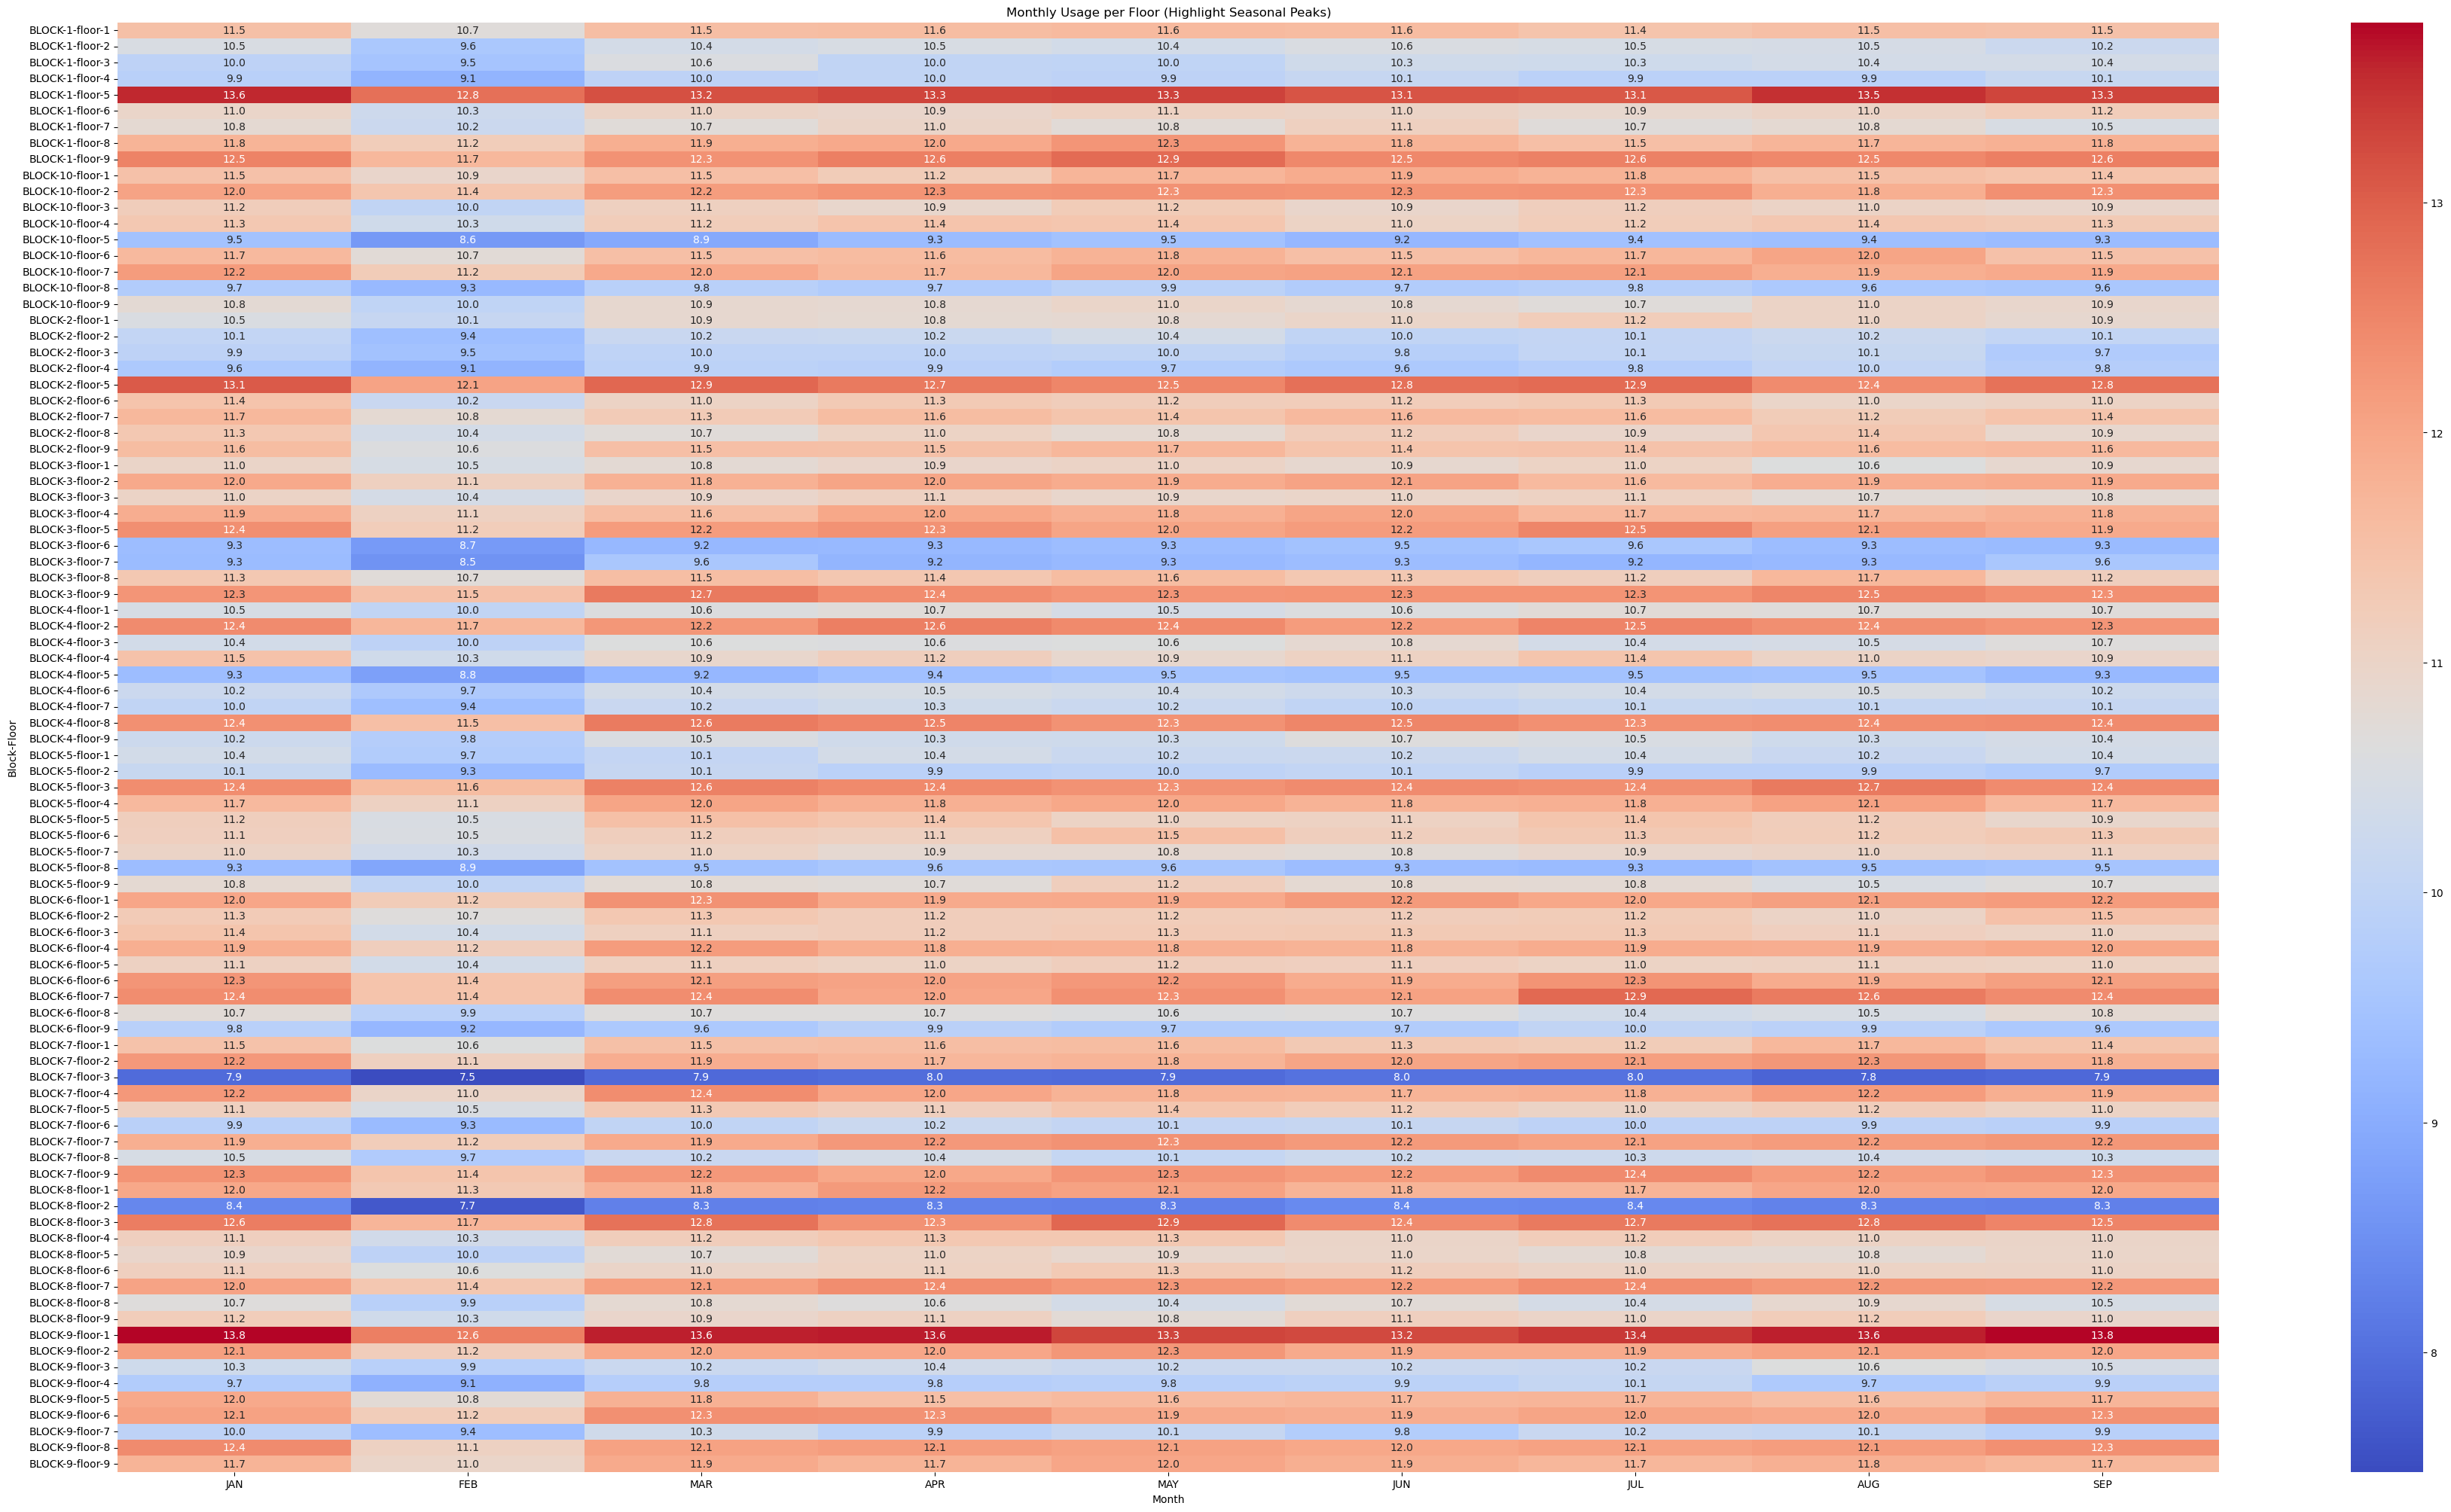

In [25]:
# Q33: Floors with seasonal variations (high highs / low lows)

# Identify floors with largest monthly range
floor_usage['Range'] = floor_usage[monthly_cols].apply(lambda x: max(x[0]) - min(x[0]), axis=1)

seasonal_floors = floor_usage.sort_values('Range', ascending=False).head(10)
print("Floors with Largest Seasonal Variations:")
print(seasonal_floors[['BLOCKS','FLOOR','Range']])

# Optional: heatmap of usage per floor
usage_matrix = df.groupby(['BLOCKS','FLOOR'])[monthly_cols].mean()
plt.figure(figsize=(45,25))
sns.heatmap(usage_matrix, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Monthly Usage per Floor (Highlight Seasonal Peaks)")
plt.ylabel("Block-Floor")
plt.xlabel("Month")
plt.show()

### 🔹 Seasonal Variation in Floor Usage

**What we checked:**  
- **Range = Max(monthly usage) – Min(monthly usage)**  
- **High range:** strong seasonal fluctuation (big peaks & dips)  
- **Low range:** stable usage  

**🏆 Top 10 Floors with Largest Seasonal Variation:**  
- **BLOCK-3 floor-2:** 15.15  
- **BLOCK-3 floor-4:** 15.09  
- **BLOCK-10 floor-3:** 15.03  
- **BLOCK-8 floor-5:** 15.01  
- **BLOCK-1 floor-8:** 14.99  
- **BLOCK-1 floor-1:** 14.90  
- **BLOCK-5 floor-5:** 14.90  
- **BLOCK-9 floor-8:** 14.89  
- **BLOCK-7 floor-8:** 14.89  
- **BLOCK-3 floor-1:** 14.88  

**👉 Interpretation:**  
- These floors are **most seasonal-sensitive**  
- Likely due to **summer spikes** and **lower usage in rainy months**


# Step 9: Equity Benchmark & Rules

In [26]:
# Q34: Equal share per family member

monthly_cols = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP']
df['Total_Usage'] = df[monthly_cols].sum(axis=1)

# Total consumption & family size
total_consumption = df['Total_Usage'].sum()
total_family_members = df['FamilySize'].sum()

fair_share_per_member = total_consumption / total_family_members
print(f"Fair Share per Family Member (Jan–Sep): {fair_share_per_member:.2f} m³")


Fair Share per Family Member (Jan–Sep): 32.81 m³


### 🔹 Fair Water Allocation per Person

**What this means:**  
- Summed all water usage (Jan–Sep) across all rooms  
- Divided by **total number of people (FamilySize sum)**  
- **Result:** 32.81 m³ per person (9 months)  

**👉 Insight:**  
- This is the **average fair water allocation per person** in the community  

**🔹 Interpretation:**  
- If everyone used water equally → each person would consume **32.81 m³** in 9 months  
- **Above this:** families are **over-consuming**  
- **Below this:** families are **under-consuming / efficient**


In [27]:
# Q35: Rooms using more than fair share
df['Fair_Allocation'] = df['FamilySize'] * fair_share_per_member
df['Overuse'] = df['Total_Usage'] - df['Fair_Allocation']

over_users = df[df['Overuse'] > 0].sort_values('Overuse', ascending=False)
print("Rooms Using More than Fair Share:\n", over_users[['BLOCKS','FLOOR','ROOMS','Total_Usage','Fair_Allocation','Overuse']].head(10))

Rooms Using More than Fair Share:
        BLOCKS    FLOOR  ROOMS  Total_Usage  Fair_Allocation    Overuse
1767  BLOCK-9  floor-2     40        42.86        32.812559  10.047441
1586  BLOCK-8  floor-4     75        42.72        32.812559   9.907441
1046  BLOCK-5  floor-8    183        42.66        32.812559   9.847441
596   BLOCK-3  floor-7    165        42.50        32.812559   9.687441
557   BLOCK-3  floor-6    126        42.50        32.812559   9.687441
855   BLOCK-4  floor-9    208        42.45        32.812559   9.637441
197   BLOCK-1  floor-9    198        42.34        32.812559   9.527441
707   BLOCK-4  floor-3     60        42.32        32.812559   9.507441
523   BLOCK-3  floor-4     92        42.20        32.812559   9.387441
492   BLOCK-3  floor-3     61        42.10        32.812559   9.287441


### 🔹 Over-Using Rooms / Floors

**What this means:**  
- Calculated **fair allocation per family = FamilySize × fair share per person**  
- Compared it to **actual water usage**  
- **👉 Shows** which rooms/floors are using **more than their fair share**  

**🔹 Interpretation:**  
- **Overuse = water consumed above fair allocation**  
- Rooms/floors with **positive overuse → over-consuming**  
- **Top overusers** (e.g., BLOCK-9 floor-2, BLOCK-8 floor-4) used **9–10 m³ more** than fair allocation  

**💡 Insight:**  
- These rooms/floors may need **monitoring, awareness, or conservation measures** to balance water usage


In [28]:
# Q36: Rooms using under their fair share

under_users = df[df['Overuse'] < 0].sort_values('Overuse')
print("Rooms Using Less than Fair Share:\n", under_users[['BLOCKS','FLOOR','ROOMS','Total_Usage','Fair_Allocation','Overuse']].head(10))

Rooms Using Less than Fair Share:
         BLOCKS    FLOOR  ROOMS  Total_Usage  Fair_Allocation    Overuse
217    BLOCK-2  floor-1      2       147.10       164.062796 -16.962796
2038  BLOCK-10  floor-4     95       147.65       164.062796 -16.412796
608    BLOCK-3  floor-8    177       148.81       164.062796 -15.252796
1544   BLOCK-8  floor-2     33       149.21       164.062796 -14.852796
646    BLOCK-3  floor-9    215       149.21       164.062796 -14.852796
704    BLOCK-4  floor-3     57       149.24       164.062796 -14.822796
2084  BLOCK-10  floor-6    141       149.74       164.062796 -14.322796
361    BLOCK-2  floor-7    146       149.91       164.062796 -14.152796
1469   BLOCK-7  floor-8    174       149.97       164.062796 -14.092796
996    BLOCK-5  floor-6    133       150.07       164.062796 -13.992796


### 🔹 Under-Using Rooms / Floors

**What this means:**  
- Compared each room/floor’s **actual water usage** with **fair allocation**  
- **👉 Rooms with negative overuse** are using **less water than fair share**  

**🔹 Interpretation:**  
- **Underuse = water consumed below fair allocation**  
- These rooms/floors are **efficient or conservative**  
- **Top underusers** (e.g., BLOCK-2 floor-1, BLOCK-10 floor-4) used **13–17 m³ less** than fair share  

**💡 Insight:**  
- These rooms/floors could be **role models for water conservation**  
- May need **less monitoring**


In [29]:
# Q37: If over-users reduced to fair share, how much water saved?

total_excess = over_users['Overuse'].sum()
print(f"Total Water Saved if Over-Users Reduced to Fair Share: {total_excess:.2f} m³")

Total Water Saved if Over-Users Reduced to Fair Share: 5358.98 m³


### 🔹 Potential Water Savings from Over-Users

**What this means:**  
- Summed the **extra water used** by rooms/floors that exceeded fair allocation  
- **👉 If over-users reduced** to fair share, total excess water could be saved  

**🔹 Interpretation:**  
- **Total water saved:** 5,358.98 m³ (Jan–Sep)  
- Shows the **potential conservation impact** if over-consuming rooms adjusted usage  

**💡 Insight:**  
- Even **small reductions per room** can add up to **large community-wide savings**


In [30]:
# Q38: How much water could be reallocated?

total_shortage = abs(under_users['Overuse'].sum())
reallocatable = min(total_excess, total_shortage)

print(f"Water that could be Reallocated to Ensure Fair Distribution: {reallocatable:.2f} m³")


Water that could be Reallocated to Ensure Fair Distribution: 5358.98 m³


### 🔹 Potential Water Reallocation

**What this means:**  
- Looked at **water underused** by rooms/floors below fair share  
- Compared with **excess used** by over-users  
- **👉 Minimum of total excess and total shortage** = water that can be **reallocated** for fair distribution  

**🔹 Interpretation:**  
- **Water that could be reallocated:** 5,358.98 m³  
- Shows the **potential to balance usage** so all rooms/floors get their **fair share**  

**💡 Insight:**  
- If **over-consuming rooms reduced usage** and **under-consuming rooms received that water**, the community could achieve **fair and efficient distribution**


# ******************************************************************************************

# 📌 Conclusion

### 📌 Actions Based on EDA Insights

**1️⃣ Monitoring & Tracking**  
- Install **water meters / smart sensors** for all rooms/floors  
- Track **monthly usage per room/floor/block**  
- Dashboards show **total, per-person, overuse/underuse trends**

**2️⃣ Awareness & Education**  
- Educate **over-users** about water-saving habits  
- Tips: **turn off taps, short showers, efficient appliances**  
- Share **monthly reports**: top over-users & efficient rooms  

**3️⃣ Incentives**  
- Reward **efficient families**: discounts, recognition (like a **“Green Family of the Month”** board), competitions  

**4️⃣ Penalties**  
- Warn & **penalize consistent over-users**  
- Base on **fair allocation benchmark**  

**5️⃣ Fair Reallocation**  
- Encourage **over-users to reduce**, under-users maintain → **balance usage (~5,359 m³)**  

**6️⃣ Infrastructure & Leak Checks**  
- Inspect **high-usage or seasonal-sensitive floors**  
- Fix **leaks, faulty meters, illegal connections**  

**7️⃣ Policies & Rules**  
- Set **max limits per family size**  
- Use **penalty + incentive system**  
- **Quarterly reviews** with dashboards  

**8️⃣ Behavioral Changes**  
- Promote **short showers, reuse water, full laundry loads**  
- Spread awareness on **community impact**  

**9️⃣ Long-Term Planning**  
- Forecast **seasonal peaks & large-family usage**  
- Implement **rainwater harvesting, greywater recycling, low-flow taps**  

**🔟 Visualization & Transparency**  
- Share **heatmaps, charts, efficiency reports**  
- **Increase accountability & motivate conservation**
